#**Datos de ventas de Hipermercados**

## Contexto y objetivo


El objetivo es analizar el conjunto de datos de ventas para identificar patrones, tendencias y oportunidades de mejora en el negocio.

**Dataset:** [Superstore Sales Dataset — Kaggle](https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting/data)  
**Fuente del archivo:** [Google Sheets](https://docs.google.com/spreadsheets/d/1kDD3AlpeNqvIBhUMrjDMZQABCWgFdnvy5howymaG870/edit?usp=sharing)

### Pregunta principal

¿Cómo evolucionaron las ventas en el tiempo y qué categorías y segmentos de clientes concentran mayor volumen de ventas?


### Subpreguntas

*  ¿Qué categoría vende más?

*  ¿Qué tipo de cliente compra más?

* ¿Cómo varían las ventas según el tiempo?


#Revisión inicial de los datos

En esta sección se realiza una primera exploración del dataset para comprender su estructura y contenido.

Se analiza la cantidad de registros, los tipos de datos de cada columna y la presencia de valores nulos.

### Librerias utilizadas

En esta sección se importan las librerías necesarias para el análisis y la visualización de los datos. Además, se configura el formato de los números para evitar la notación científica y facilitar la lectura de los resultados.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

pd.options.display.float_format = '{:,.0f}'.format

###Carga del dataset

Se carga el archivo de datos utilizando la biblioteca pandas. Esto permite ver la información y realizar el análisis correspondiente.

In [2]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ventas.csv', encoding='latin-1')

print('Datos cargados correctamente.')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Mounted at /content/drive
Datos cargados correctamente.
Dimensiones: 9800 filas x 18 columnas


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,262
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",732
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,15
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,958
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22


###Exploración inicial

Antes de empezar con el análisis, primero reviso cómo están los datos.

Esto es importante porque si los datos tienen errores o cosas raras, después los resultados pueden salir mal. Básicamente, si los datos están mal, el análisis también.

En esta parte me fijo en algunas cosas clave:

- **Tipos de datos**

- **Valores nulos**

- **Duplicados**

- **Estadísticas generales**




In [3]:
print("Tipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nEstadísticas:")
df.describe()

Tipos de datos:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Valores nulos:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicados:
0

Estadísticas:


,Row ID,Postal Code,Sales
count,"9,800","9,789","9,800"
mean,"4,900","55,273",231
std,"2,829","32,041",627
min,1,"1,040",0
25%,"2,451","23,223",17
50%,"4,900","58,103",54
75%,"7,350","90,008",211
max,"9,800","99,301","22,638"


##Limpieza de los datos
En esta etapa se preparan los datos para el análisis. Se convierten las columnas de fecha de texto a formato fecha, se extraen el año y el mes como variables nuevas, se eliminan las columnas que no aportan información relevante y se renombran las columnas al español para analizar de forma más clara.

In [4]:
# Convierto las columnas de fecha de texto a formato fecha
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [5]:
# Extraigo el año y el mes de la fecha de pedido
df['Año'] = df['Order Date'].dt.year
df['Mes'] = df['Order Date'].dt.month

In [6]:
#Elimino columnas que no son utiles en el análisis
df.drop(columns=['Row ID', 'Country', 'Postal Code', 'Product ID', 'Customer ID'], inplace=True)

In [7]:
#Verifico que los cambios hayan quedaron bien
print("Tipos de datos actualizados:")
print(df.dtypes)
print(f"\nDimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")

Tipos de datos actualizados:
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer Name            object
Segment                  object
City                     object
State                    object
Region                   object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Año                       int32
Mes                       int32
dtype: object

Dimensiones finales: 9800 filas x 15 columnas


In [8]:
#Renombro las columnas de ingles a español
df.rename(columns={
    'Order ID'      : 'ID Pedido',
    'Order Date'    : 'Fecha Pedido',
    'Ship Date'     : 'Fecha Envío',
    'Ship Mode'     : 'Modo Envío',
    'Customer Name' : 'Cliente',
    'Segment'       : 'Segmento',
    'City'          : 'Ciudad',
    'State'         : 'Estado',
    'Region'        : 'Region',
    'Category'      : 'Categoria',
    'Sub-Category'  : 'Subcategoria',
    'Product Name'  : 'Producto',
    'Sales'         : 'Ventas'
}, inplace=True)

print("Columnas renombradas:")
print(df.columns.tolist())

Columnas renombradas:
['ID Pedido', 'Fecha Pedido', 'Fecha Envío', 'Modo Envío', 'Cliente', 'Segmento', 'Ciudad', 'Estado', 'Region', 'Categoria', 'Subcategoria', 'Producto', 'Ventas', 'Año', 'Mes']


## Análisis del compotamiento de ventas

In [9]:
# Ventas por categoría
df.groupby('Categoria')['Ventas'].sum().sort_values(ascending=False)

,Ventas
Categoria,
Technology,"827,456"
Furniture,"728,659"
Office Supplies,"705,422"


**¿Qué categoría vende más?**

El resultado muestra que la categoría que presenta mayores ventas es Technology, seguida por Furniture y Office Supplies.

Esto desmuestra que los productos tecnológicos son los que generan mayor ingreso dentro del negocio, por lo que representan una categoría clave.

In [10]:
# Ventas en el tiempo
df.groupby('Mes')['Ventas'].sum()

,Ventas
Mes,
1,"94,292"
2,"59,371"
3,"197,574"
4,"136,283"
5,"154,087"
6,"145,838"
7,"145,536"
8,"157,316"
9,"300,103"


**¿Cómo varían las ventas según el tiempo?**

Las ventas varían a lo largo del año, con picos más altos en algunos meses específicos.

Se puede notar que en los ultimos meses del año ( septiembre, octubre, noviembre y diciembre) las ventas tienden a ser más altas, lo que podría estar relacionado con mayor demanda o fechas comerciales.

In [11]:
# Ventas por segmento
df.groupby('Segmento')['Ventas'].sum().sort_values(ascending=False)

,Ventas
Segmento,
Consumer,"1,148,061"
Corporate,"688,494"
Home Office,"424,982"


**¿Qué tipo de cliente compra más?**

Los clientes que más compran son los de Consumer, seguido por Corporate y Home Office.

Esto muestra que la mayor parte de las ventas proviene de clientes individuales, lo que sugiere que el negocio está más orientado al consumidor final.

**¿Cómo evolucionaron las ventas en el tiempo y qué categorías y segmentos de clientes concentran mayor volumen de ventas?**

La evolucion de las ventas a lo largo del tiempo muestran variaciones con ciertos períodos de mayor actividad.

En cuanto a las categorías, Technology concentra el mayor volumen de ventas, mientras que el segmento Consumer es el que más contribuye al total.

Esto permite identificar tanto los productos más importantes como el tipo de cliente principal del negocio. Esto podría servir para tomar decisiones comerciales, como enfocar estrategias en las categorías más vendidas o en los tipos de clientes más activos.

## Visualización de datos
En este paso vemos los resultados del análisis con gráficos, con el objetivo de visualizar de forma clara los patrones y tendencias en las ventas.

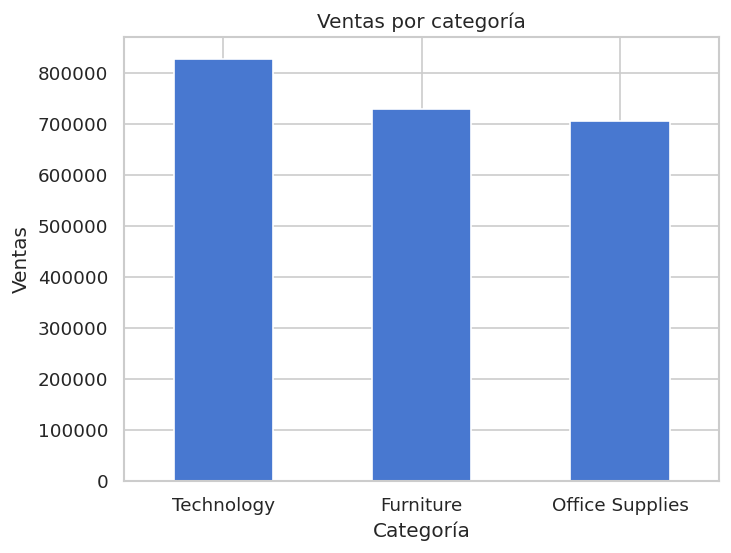

In [12]:
#Ventas por categoría
ventas_categoria = df.groupby('Categoria')['Ventas'].sum().sort_values(ascending=False)

ventas_categoria.plot(kind='bar')
plt.title('Ventas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas')
plt.xticks(rotation=0)
plt.show()

Este gráfico muestra que la categoría Technology es la que concentra mayor volumen de ventas, seguida por Furniture y Office Supplies. Esto refuerza la idea de que los productos tecnológicos son los más importantes dentro del negocio.

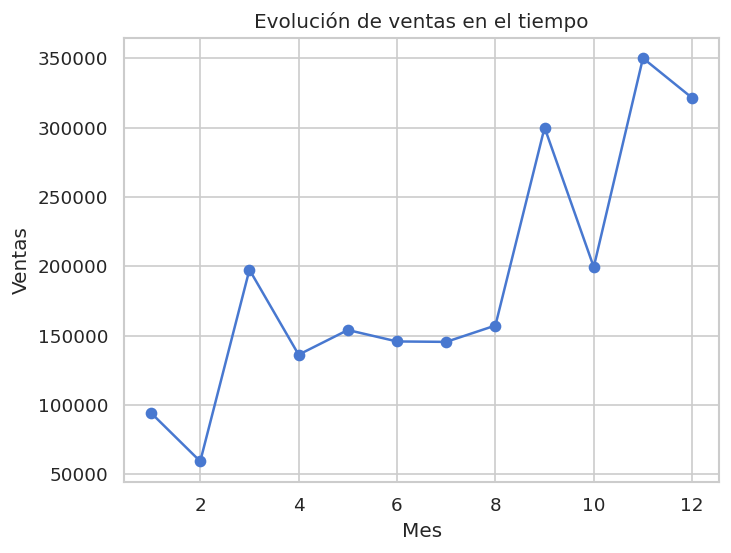

In [13]:
#Ventas en el tiempo
ventas_tiempo = df.groupby('Mes')['Ventas'].sum()

ventas_tiempo.plot(kind='line', marker='o')
plt.title('Evolución de ventas en el tiempo')
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.show()

En este gráfico se permite ver cómo varían las ventas a lo largo del tiempo, identificando períodos con mayor actividad.

Se destacan picos especialmente hacia fin de año.

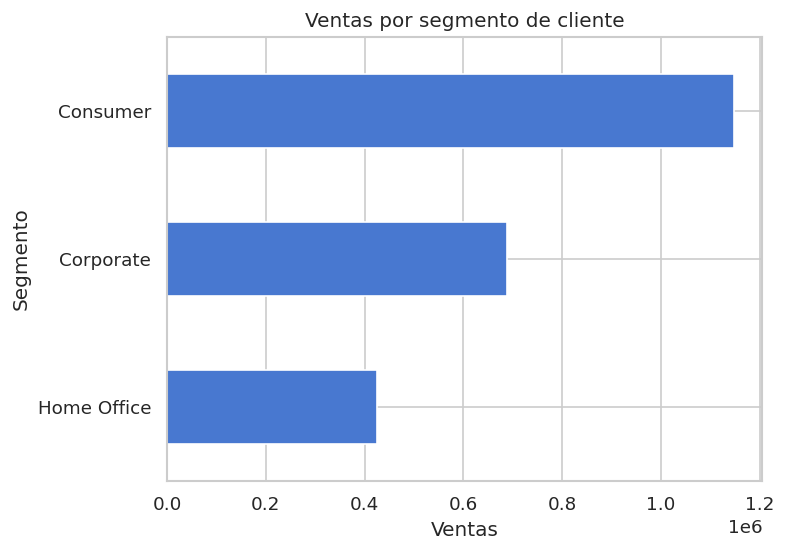

In [14]:
#Ventas por segmento
ventas_segmento = df.groupby('Segmento')['Ventas'].sum().sort_values()

ventas_segmento.plot(kind='barh')
plt.title('Ventas por segmento de cliente')
plt.xlabel('Ventas')
plt.ylabel('Segmento')
plt.show()

Se visualiza que el segmento Consumer lidera en volumen de ventas, seguido por Corporate y Home Office.

Esto confirma que el principal público del negocio son los consumidores individuales.

##KPIs
En esta sección se calculan indicadores clave para resumir la información más importante del dataset


In [15]:
#Ventas totales
ventas_totales = df['Ventas'].sum()
ventas_totales

np.float64(2261536.7827000003)

Este valor representa el total de ingresos generados por las ventas.

In [16]:
#Categoría con más ventas
df.groupby('Categoria')['Ventas'].sum().idxmax()

'Technology'

Esta es la categoría que concentra el mayor volumen de ventas

In [17]:
#Mes con mas ventas
df.groupby('Mes')['Ventas'].sum().idxmax()

np.int32(11)

Este resultado indica el período con mayor nivel de ventas

In [18]:
#Cliente que mas compra
df.groupby('Segmento')['Ventas'].sum().idxmax()

'Consumer'

Este es el grupo de clientes que genera mayor volumen de ventas

##Conclusion

En base al análisis realizado, se pueden identificar varios puntos importantes.

En primer lugar, las ventas muestran variaciones a lo largo del tiempo, con mayor actividad en ciertos meses, especialmente a fin de año.

En cuanto a las categorías, Technology es la que concentra el mayor volumen de ventas, lo que la convierte en una de las más importantes para el negocio.

Por otro lado, el tipo de cliente que más contribuye a las ventas es el Consumer, lo que indica que el negocio está principalmente orientado al consumidor final.

Estos resultados pueden servir para tomar decisiones estratégicas, como enfocar esfuerzos en las categorías más vendidas y en los clientes que generan mayor ingreso.

In [20]:
df.to_csv('ventas_limpio.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')